In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
from sklearn.datasets import load_diabetes
from scipy.stats import norm

!pip install tabicl
from tabicl import TabICLRegressor

# cobertura alvo de 90%
alpha = 0.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.9/252.9 kB 10.0 MB/s eta 0:00:00


In [4]:
# ============================================
# BLOCO 2: CARREGAR E PREPARAR OS DADOS
# ============================================

# Carregar os dados
df = pd.read_csv('/content/noticias.csv')

print(f"📊 Total de notícias: {len(df)}")
print(f"📋 Colunas: {df.columns.tolist()}")
print("\n🔍 Primeiras linhas:")
display(df.head())

# Verificar valores nulos
print("\n🔍 Valores nulos por coluna:")
print(df.isnull().sum())

# Preencher valores nulos na coluna de texto
df['texto_sem_stopwords'] = df['texto_sem_stopwords'].fillna('')

📊 Total de notícias: 2000
📋 Colunas: ['titulo', 'data', 'visitas', 'texto', 'texto_limpo', 'texto_sem_stopwords']

🔍 Primeiras linhas:


,titulo,data,visitas,texto,texto_limpo,texto_sem_stopwords
0,STJD indefere pedido de suspensão e Abel Ferre...,11/4/2026 16:47,141,O Palmeiras terá uma nova rodada de desafios n...,o palmeiras tera uma nova rodada de desafios n...,palmeiras nova rodada desafios campeonato bras...
1,Nubank Anuncia Amistoso Imperdível: Palmeiras ...,11/4/2026 16:47,129,O Nubank está explorando a possibilidade de or...,o nubank esta explorando a possibilidade de or...,nubank explorando possibilidade organizar amis...
2,STJD Recusa Suspensão de Abel Ferreira; Palmei...,11/4/2026 16:47,105,A Sociedade Esportiva Palmeiras manifestou sua...,a sociedade esportiva palmeiras manifestou sua...,sociedade esportiva palmeiras manifestou insat...
3,Palmeiras encerra treinos para o Dérbi com Vit...,11/4/2026 14:27,276,"Na manhã deste sábado (11), a Academia de Fute...",na manha deste sabado 11 a academia de futebol...,manha deste sabado 11 academia futebol palco u...
4,Messi Pode Anunciar Amistoso Histórico em São ...,11/4/2026 14:07,246,"A co-fundadora do Nubank, Cristina Junqueira, ...",a co fundadora do nubank cristina junqueira re...,co fundadora nubank cristina junqueira revelou...



🔍 Valores nulos por coluna:
titulo                  0
data                    0
visitas                 0
texto                  18
texto_limpo            18
texto_sem_stopwords    18
dtype: int64


In [5]:
# ============================================
# BLOCO 3: CRIAR VARIÁVEL TARGET
# ============================================

# Definir o threshold: 20% das notícias com mais visitas
threshold = np.percentile(df['visitas'], 80)  # 80º percentil = top 20%

# Criar a variável target: 1 = Hot (top 20%), 0 = Not Hot
df['hot'] = (df['visitas'] >= threshold).astype(int)

print(f"\n🎯 Threshold para ser considerado HOT: {threshold:.0f} visitas")
print(f"\n📈 Distribuição da variável target:")
print(df['hot'].value_counts())
print(f"   Hot (1): {df['hot'].sum()} notícias ({df['hot'].mean()*100:.1f}%)")
print(f"   Not Hot (0): {len(df) - df['hot'].sum()} notícias ({(1-df['hot'].mean())*100:.1f}%)")


🎯 Threshold para ser considerado HOT: 1879 visitas

📈 Distribuição da variável target:
hot
0    1600
1     400
Name: count, dtype: int64
   Hot (1): 400 notícias (20.0%)
   Not Hot (0): 1600 notícias (80.0%)


In [6]:
# ============================================
# BLOCO 5: DIVISÃO DOS DADOS
# ============================================

X = df['texto_sem_stopwords']
y = df['hot']

# Primeiro separar treino (60%) e temporário (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Depois dividir o temporário em validação (20%) e teste (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\n📊 Divisão dos dados:")
print(f"   Treino: {len(X_train)} notícias ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Validação: {len(X_val)} notícias ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Teste: {len(X_test)} notícias ({len(X_test)/len(df)*100:.1f}%)")

# Verificar a distribuição da target em cada conjunto
print("\n🎯 Distribuição da target em cada conjunto:")
print(f"   Treino - Hot: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Validação - Hot: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"   Teste - Hot: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


📊 Divisão dos dados:
   Treino: 1200 notícias (60.0%)
   Validação: 400 notícias (20.0%)
   Teste: 400 notícias (20.0%)

🎯 Distribuição da target em cada conjunto:
   Treino - Hot: 240 (20.0%)
   Validação - Hot: 80 (20.0%)
   Teste - Hot: 80 (20.0%)



🤖 TREINANDO MODELO EXTRA: TabICL (In-Context Learning)

📝 Vetorizando texto com TF-IDF...

📉 Reduzindo dimensionalidade com SVD (TF-IDF → 200 componentes)...
   Shape treino após SVD: (1200, 200)
   Variância explicada: 48.29%

🔄 Ajustando TabICL (download do checkpoint na 1ª vez)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

🔍 Gerando predições no conjunto de teste...

📊 RESULTADOS - TabICL
   Acurácia:    0.8075
   Precisão:    0.5517
   Recall:      0.2000
   F1-Score:    0.2936
   ROC-AUC:     0.7448

📋 Relatório de Classificação:
              precision    recall  f1-score   support

     Not Hot       0.83      0.96      0.89       320
         Hot       0.55      0.20      0.29        80

    accuracy                           0.81       400
   macro avg       0.69      0.58      0.59       400
weighted avg       0.77      0.81      0.77       400



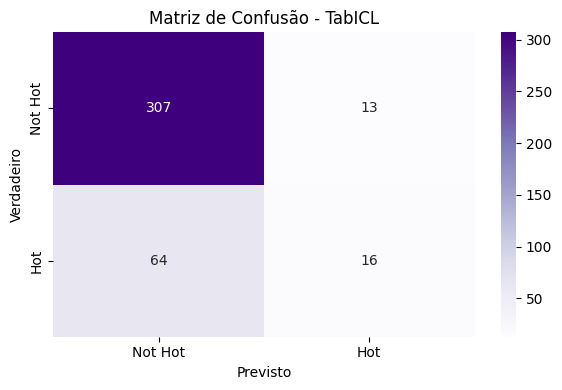

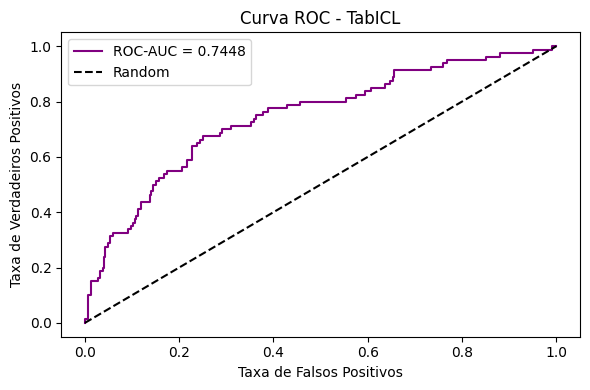


✅ Modelo TabICL finalizado!
📊 Métricas salvas em 'metrics_tabicl'


In [9]:
# ============================================
# BLOCO EXTRA: TabICL para Classificação Binária
# ============================================
# Instalação (rode uma vez):
# !pip install tabicl

from tabicl import TabICLClassifier
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n" + "="*70)
print("🤖 TREINANDO MODELO EXTRA: TabICL (In-Context Learning)")
print("="*70)

# TabICL opera sobre features densas — usar a matriz TF-IDF convertida para array denso
# AVISO: com 5000 features isso pode ser pesado; reduzir dimensionalidade ajuda
from sklearn.decomposition import TruncatedSVD

# Adicionar o passo de vetorização TF-IDF
print("\n📝 Vetorizando texto com TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("\n📉 Reduzindo dimensionalidade com SVD (TF-IDF → 200 componentes)...")
svd = TruncatedSVD(n_components=200, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

print(f"   Shape treino após SVD: {X_train_svd.shape}")
print(f"   Variância explicada: {svd.explained_variance_ratio_.sum():.2%}")

# Instanciar e treinar o TabICL
# kv_cache=True acelera muito quando o conjunto de treino é fixo
tabicl = TabICLClassifier(kv_cache=True)

print("\n🔄 Ajustando TabICL (download do checkpoint na 1ª vez)...")
tabicl.fit(X_train_svd, y_train.values)

# Predições no conjunto de teste
print("🔍 Gerando predições no conjunto de teste...")
y_pred_tabicl = tabicl.predict(X_test_svd)
y_prob_tabicl = tabicl.predict_proba(X_test_svd)[:, 1]

# Métricas
acc  = accuracy_score(y_test, y_pred_tabicl)
prec = precision_score(y_test, y_pred_tabicl, zero_division=0)
rec  = recall_score(y_test, y_pred_tabicl, zero_division=0)
f1   = f1_score(y_test, y_pred_tabicl, zero_division=0)
auc  = roc_auc_score(y_test, y_prob_tabicl)

print(f"\n{'='*60}")
print(f"📊 RESULTADOS - TabICL")
print(f"{'='*60}")
print(f"   Acurácia:    {acc:.4f}")
print(f"   Precisão:    {prec:.4f}")
print(f"   Recall:      {rec:.4f}")
print(f"   F1-Score:    {f1:.4f}")
print(f"   ROC-AUC:     {auc:.4f}")
print(f"\n📋 Relatório de Classificação:")
print(classification_report(y_test, y_pred_tabicl, target_names=['Not Hot', 'Hot']))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_tabicl)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Hot', 'Hot'],
            yticklabels=['Not Hot', 'Hot'])
plt.title('Matriz de Confusão - TabICL')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_tabicl)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='purple', label=f'ROC-AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - TabICL')
plt.legend()
plt.tight_layout()
plt.show()

# Salvar métricas
metrics_tabicl = {
    'model': 'TabICL',
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'roc_auc': auc
}

print(f"\n✅ Modelo TabICL finalizado!")
print(f"📊 Métricas salvas em 'metrics_tabicl'")